Gefundene Dateien: 70
Anzahl Klassen (ohne Hintergrund): 4

=== Gesamt-Konfusionsmatrix (ohne Hintergrund, absolut) ===
[[475031480     54821   2899127     43906]
 [   172618 366122378    916943    506775]
 [  7238252   1648523 724972519   5757309]
 [    40069    307817  15654239 894781302]]

=== TP / FP / FN / TN pro Klasse (in % aller Pixel über alle Epochen) ===
Klasse 0: TP=19.031%  FP= 0.298%  FN= 0.120%  TN=80.551%  Precision=98.456%
Klasse 1: TP=14.667%  FP= 0.081%  FN= 0.064%  TN=85.188%  Precision=99.454%
Klasse 2: TP=29.044%  FP= 0.780%  FN= 0.587%  TN=69.590%  Precision=97.385%
Klasse 3: TP=35.846%  FP= 0.253%  FN= 0.641%  TN=63.260%  Precision=99.300%

Macro-Precision: 98.648%
Micro-Precision: 98.588%


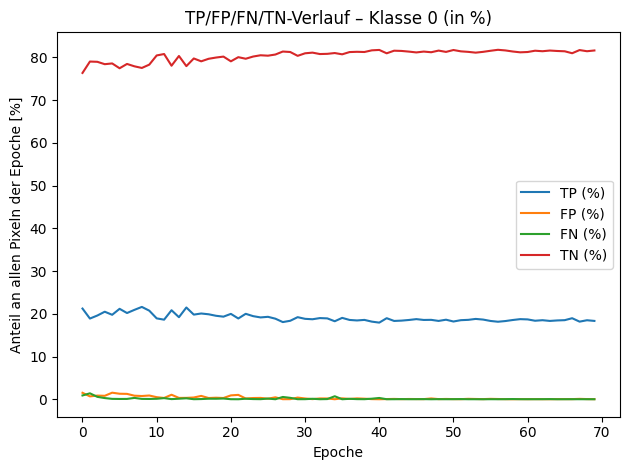

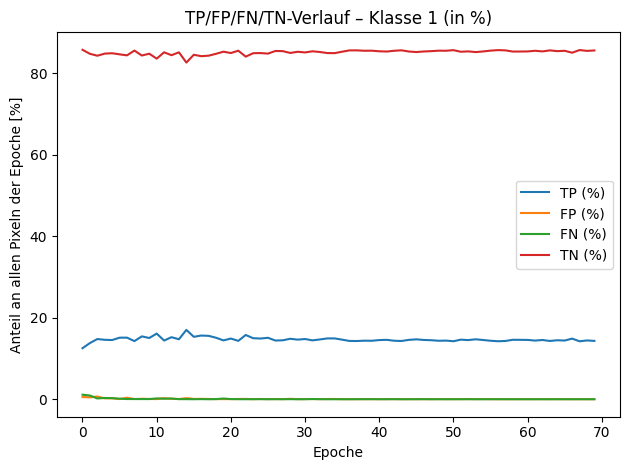

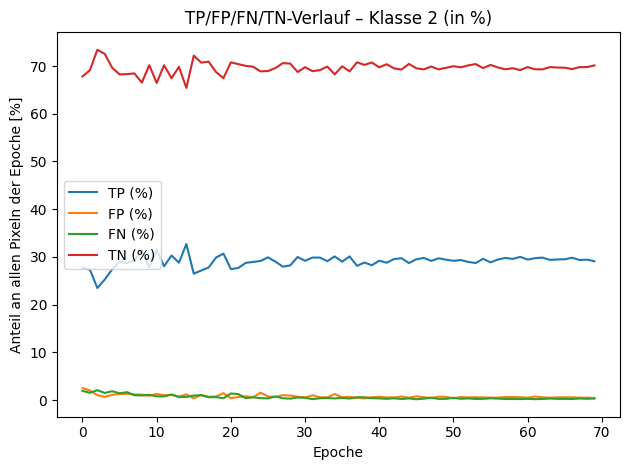

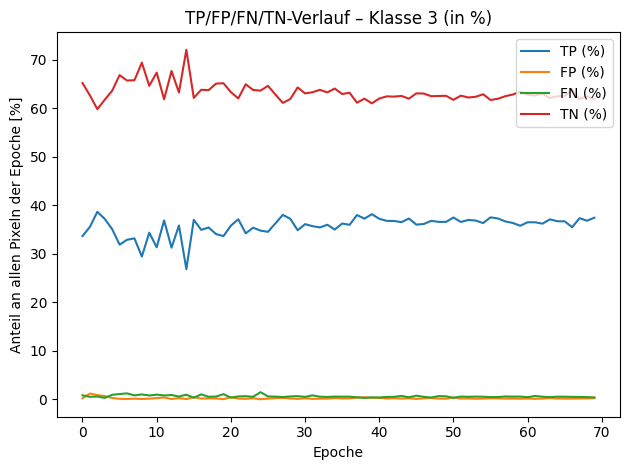

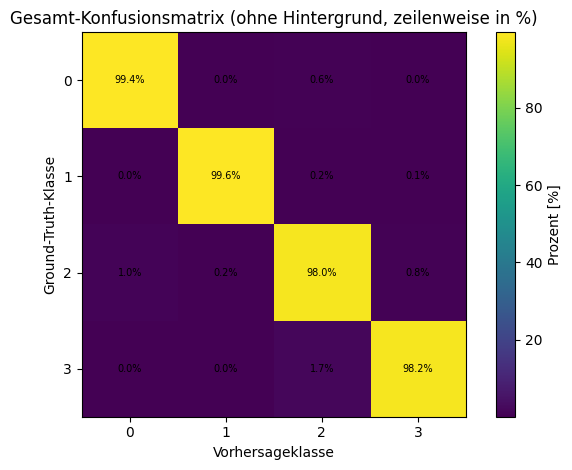

In [5]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Einstellungen
# ============================================

# Ordner, in dem die CSVs liegen
CONF_DIR = "."
# Dateimuster für die Confusion-Matrizen ohne Hintergrund
PATTERN = "confmat_noBG_epoch_*.csv"

# Plots speichern?
SAVE_PLOTS = False
PLOT_DIR = "confmat_plots"

# ============================================
# Hilfsfunktionen
# ============================================

def extract_epoch_index(path):
    """
    Extrahiert die Epoche aus dem Dateinamen, z.B. ...epoch_000.csv -> 0.
    Falls nicht gefunden, wird 0 zurückgegeben.
    """
    base = os.path.basename(path)
    m = re.search(r"epoch_(\d+)", base)
    if m:
        return int(m.group(1))
    return 0

def compute_tp_fp_fn_tn(cm):
    """
    Berechnet TP, FP, FN, TN für jede Klasse aus einer
    Multiclass-Konfusionsmatrix (ohne Hintergrund).

    cm: numpy-Array (C x C)

    Rückgabe:
        tp, fp, fn, tn  (jeweils 1D-Arrays der Länge C, absolute Zahlen)
    """
    num_classes = cm.shape[0]
    tp = np.zeros(num_classes, dtype=np.int64)
    fp = np.zeros(num_classes, dtype=np.int64)
    fn = np.zeros(num_classes, dtype=np.int64)
    tn = np.zeros(num_classes, dtype=np.int64)

    total = cm.sum()

    for k in range(num_classes):
        tp_k = cm[k, k]
        fn_k = cm[k, :].sum() - tp_k
        fp_k = cm[:, k].sum() - tp_k
        tn_k = total - tp_k - fn_k - fp_k

        tp[k] = tp_k
        fn[k] = fn_k
        fp[k] = fp_k
        tn[k] = tn_k

    return tp, fp, fn, tn

# ============================================
# Hauptlogik
# ============================================

if __name__ == "__main__":
    # --- Dateien suchen und nach Epoche sortieren ---
    search_pattern = os.path.join(CONF_DIR, PATTERN)
    files = glob.glob(search_pattern)
    if not files:
        raise FileNotFoundError(f"Keine Dateien gefunden für Muster: {search_pattern}")

    files = sorted(files, key=extract_epoch_index)

    # Einmal einlesen, um Dimension zu kennen
    first_cm = np.loadtxt(files[0], delimiter=",", dtype=np.int64)
    num_classes = first_cm.shape[0]
    num_epochs = len(files)

    print(f"Gefundene Dateien: {num_epochs}")
    print(f"Anzahl Klassen (ohne Hintergrund): {num_classes}")

    # Historien (TP/FP/FN/TN) in Prozent pro Epoche & Klasse
    tp_hist_pct = np.zeros((num_epochs, num_classes), dtype=float)
    fp_hist_pct = np.zeros((num_epochs, num_classes), dtype=float)
    fn_hist_pct = np.zeros((num_epochs, num_classes), dtype=float)
    tn_hist_pct = np.zeros((num_epochs, num_classes), dtype=float)

    # Gesamtmatrix (absolute Werte) über alle Epochen
    total_cm = np.zeros_like(first_cm, dtype=np.int64)

    epoch_indices = []

    for i, path in enumerate(files):
        cm = np.loadtxt(path, delimiter=",", dtype=np.int64)
        if cm.shape != total_cm.shape:
            raise ValueError(
                f"Matrix-Shape in {path} = {cm.shape} passt nicht zur erwarteten Shape {total_cm.shape}"
            )

        total_cm += cm

        epoch_idx = extract_epoch_index(path)
        epoch_indices.append(epoch_idx)

        # TP/FP/FN/TN (absolut) für diese Epoche
        tp_abs, fp_abs, fn_abs, tn_abs = compute_tp_fp_fn_tn(cm)

        total_pixels_epoch = cm.sum()
        if total_pixels_epoch == 0:
            # Degenerativer Fall, dann alles 0%
            continue

        # In Prozent der Gesamtpixel dieser Epoche umrechnen
        tp_hist_pct[i, :] = tp_abs / total_pixels_epoch * 100.0
        fp_hist_pct[i, :] = fp_abs / total_pixels_epoch * 100.0
        fn_hist_pct[i, :] = fn_abs / total_pixels_epoch * 100.0
        tn_hist_pct[i, :] = tn_abs / total_pixels_epoch * 100.0

    epoch_indices = np.array(epoch_indices)

    # ============================================
    # TP/FP/FN/TN + Precision aus Gesamtmatrix (in %)
    # ============================================
    tp_total, fp_total, fn_total, tn_total = compute_tp_fp_fn_tn(total_cm)
    total_pixels_all = total_cm.sum()

    # TP/FP/FN/TN pro Klasse in Prozent (bezogen auf alle Pixel über alle Epochen)
    tp_total_pct = tp_total / total_pixels_all * 100.0
    fp_total_pct = fp_total / total_pixels_all * 100.0
    fn_total_pct = fn_total / total_pixels_all * 100.0
    tn_total_pct = tn_total / total_pixels_all * 100.0

    # Precision pro Klasse (in %)
    precision_per_class_pct = np.zeros(num_classes, dtype=float)
    for k in range(num_classes):
        denom = tp_total[k] + fp_total[k]
        if denom > 0:
            precision_per_class_pct[k] = tp_total[k] / denom * 100.0
        else:
            precision_per_class_pct[k] = np.nan

    # Macro-/Micro-Precision (ebenfalls in %)
    macro_precision_pct = np.nanmean(precision_per_class_pct)
    micro_precision_pct = tp_total.sum() / (tp_total.sum() + fp_total.sum()) * 100.0

    # ============================================
    # Ausgaben im Terminal
    # ============================================
    print("\n=== Gesamt-Konfusionsmatrix (ohne Hintergrund, absolut) ===")
    print(total_cm)

    print("\n=== TP / FP / FN / TN pro Klasse (in % aller Pixel über alle Epochen) ===")
    for k in range(num_classes):
        print(
            f"Klasse {k}: "
            f"TP={tp_total_pct[k]:6.3f}%  "
            f"FP={fp_total_pct[k]:6.3f}%  "
            f"FN={fn_total_pct[k]:6.3f}%  "
            f"TN={tn_total_pct[k]:6.3f}%  "
            f"Precision={precision_per_class_pct[k]:6.3f}%"
        )

    print(f"\nMacro-Precision: {macro_precision_pct:.3f}%")
    print(f"Micro-Precision: {micro_precision_pct:.3f}%")

    # ============================================
    # Plots: TP/FP/FN/TN-Verlauf pro Klasse (in %)
    # ============================================
    if SAVE_PLOTS and not os.path.exists(PLOT_DIR):
        os.makedirs(PLOT_DIR, exist_ok=True)

    for k in range(num_classes):
        plt.figure()
        plt.plot(epoch_indices, tp_hist_pct[:, k], label="TP (%)")
        plt.plot(epoch_indices, fp_hist_pct[:, k], label="FP (%)")
        plt.plot(epoch_indices, fn_hist_pct[:, k], label="FN (%)")
        plt.plot(epoch_indices, tn_hist_pct[:, k], label="TN (%)")
        plt.xlabel("Epoche")
        plt.ylabel("Anteil an allen Pixeln der Epoche [%]")
        plt.title(f"TP/FP/FN/TN-Verlauf – Klasse {k} (in %)")
        plt.legend()
        plt.tight_layout()

        if SAVE_PLOTS:
            out_path = os.path.join(PLOT_DIR, f"tp_fp_fn_tn_class_{k}_percent.png")
            plt.savefig(out_path, dpi=150)
        else:
            plt.show()
        plt.close()

    # ============================================
    # Heatmap der Gesamt-Konfusionsmatrix (in %)
    # ============================================

    # Zeilenweise normalisieren: jede Zeile = GT-Klasse, Summe 100% -> Verteilung der Vorhersagen
    row_sums = total_cm.sum(axis=1, keepdims=True).astype(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_row_pct = np.divide(total_cm, row_sums, where=row_sums != 0) * 100.0

    plt.figure()
    im = plt.imshow(cm_row_pct, interpolation="nearest")
    plt.title("Gesamt-Konfusionsmatrix (ohne Hintergrund, zeilenweise in %)")
    cbar = plt.colorbar(im)
    cbar.set_label("Prozent [%]")
    plt.xlabel("Vorhersageklasse")
    plt.ylabel("Ground-Truth-Klasse")

    ticks = np.arange(num_classes)
    plt.xticks(ticks, ticks)
    plt.yticks(ticks, ticks)

    # Prozentwerte in Zellen schreiben
    for i in range(num_classes):
        for j in range(num_classes):
            val = cm_row_pct[i, j]
            if np.isnan(val):
                txt = "n/a"
            else:
                txt = f"{val:.1f}%"
            plt.text(j, i, txt, ha="center", va="center", fontsize=7)

    plt.tight_layout()

    if SAVE_PLOTS:
        out_path = os.path.join(PLOT_DIR, "confusion_matrix_overall_heatmap_percent.png")
        plt.savefig(out_path, dpi=150)
        print(f"\nHeatmap gespeichert unter: {out_path}")
    else:
        plt.show()
    plt.close()